<a href="https://colab.research.google.com/github/Arooba93/MyProjects/blob/main/ResNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
from google.colab import drive

# 1. Smart Mount
if not os.path.exists('/content/drive/MyDrive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted! Skipping mount step.")

# 2. Extract Data
zip_path = '/content/drive/MyDrive/archive.zip' # Make sure this matches your file name
extract_dir = '/content/medical_data'

if not os.path.exists(f"{extract_dir}/chest_xray"):
    print("Extracting archive.zip... please wait.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete!")
else:
    print("Data already extracted.")

# VERIFY: Count images
# Note: If your zip extracted without a 'chest_xray' folder, adjust this path
base_dir = f"{extract_dir}/chest_xray"
train_normal = len(os.listdir(f"{base_dir}/train/NORMAL"))
train_pneumonia = len(os.listdir(f"{base_dir}/train/PNEUMONIA"))

print(f"\nFound {train_normal} Normal and {train_pneumonia} Pneumonia training images.")

Mounting Google Drive...
Mounted at /content/drive
Extracting archive.zip... please wait.
Extraction complete!

Found 1341 Normal and 3875 Pneumonia training images.


Using device: cuda:0


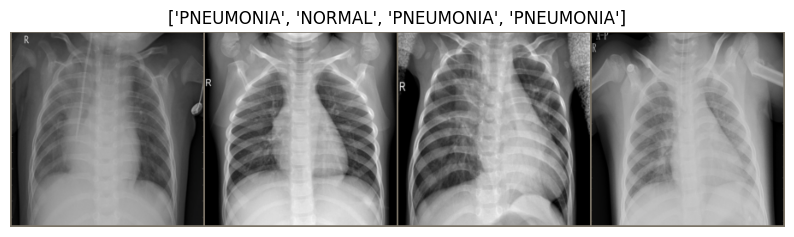

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Standard ImageNet transforms for ResNet
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(base_dir, 'train'), data_transforms)
test_dataset = datasets.ImageFolder(os.path.join(base_dir, 'test'), data_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2,       # Uses multiple CPU cores to load images in the background
    pin_memory=True,     # Locks data in fast memory for instant GPU transfer
    prefetch_factor=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# VERIFY: Visualize one batch
inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:4])

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
    inp = np.clip(std * inp + mean, 0, 1)
    plt.figure(figsize=(10, 4))
    plt.imshow(inp)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()

imshow(out, title=[train_dataset.classes[x] for x in classes[:4]])


--- Training ResNet Model A  ---


Epoch 1/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 1/9 | Loss: 0.2664 | Accuracy: 0.8944


Epoch 2/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 2/9 | Loss: 0.1639 | Accuracy: 0.9387


...

Epoch 7/9 | Loss: 0.0985 | Accuracy: 0.9666


Epoch 8/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 8/9 | Loss: 0.0911 | Accuracy: 0.9672


Epoch 9/9:   0%|          | 0/163 [00:00<?, ?it/s]

Epoch 9/9 | Loss: 0.0863 | Accuracy: 0.9707


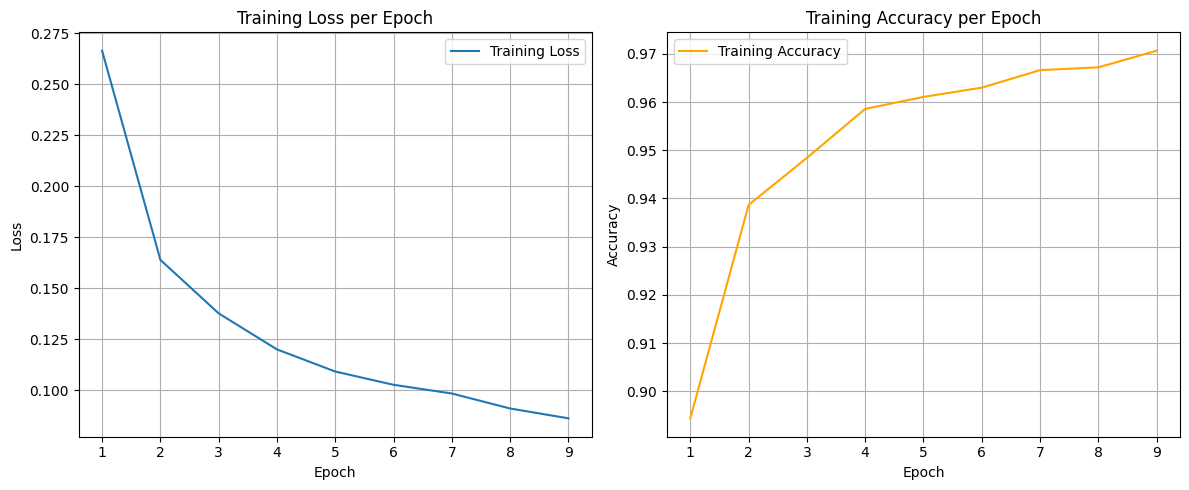

✅ Saved ResNet A to /content/drive/MyDrive/ResNet_A.pth


In [ ]:
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm # Import tqdm for progress bar

print("\n--- Training ResNet Model A  ---")

# 1. Load ResNet-50
resnet_A = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 2. Freeze the backbone
for param in resnet_A.parameters():
    param.requires_grad = False

# 3. Replace the final layer (ResNet uses .fc instead of .heads)
num_ftrs = resnet_A.fc.in_features
resnet_A.fc = nn.Linear(num_ftrs, 2)
resnet_A = resnet_A.to(device)

# 4. Train
criterion = nn.CrossEntropyLoss()
optimizer_A = optim.Adam(resnet_A.fc.parameters(), lr=0.001)

resnet_A.train()
history_A_loss = []
history_A_acc = []

epochs = 9 # Set epochs to 9

for epoch in range(epochs):
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    # Wrap train_loader with tqdm for a progress bar
    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_A.zero_grad()
        outputs = resnet_A(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_A.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_predictions / total_predictions
    history_A_loss.append(epoch_loss)
    history_A_acc.append(epoch_acc)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

# Plotting training loss and accuracy
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), history_A_loss, label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), history_A_acc, label='Training Accuracy', color='orange')
plt.title('Training Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save Model A
path_A = '/content/drive/MyDrive/ResNet_A.pth'
torch.save(resnet_A.state_dict(), path_A)
print(f"✅ Saved ResNet A to {path_A}")

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
path_A = '/content/drive/MyDrive/ResNet_A.pth'

# 1. Rebuild the blank ResNet50 skeleton
resnet_A = models.resnet50(weights=None)
resnet_A.fc = nn.Linear(resnet_A.fc.in_features, 2)

# 2. Load your saved weights into the skeleton
resnet_A.load_state_dict(torch.load(path_A, map_location=device, weights_only=True))

# 3. Move the model to the GPU
resnet_A = resnet_A.to(device)

print(f"Model successfully loaded from {path_A}")
print("resnet_A is now in memory and ready for further fine-tuning!")

Model successfully loaded from /content/drive/MyDrive/ResNet_A.pth
resnet_A is now in memory and ready for further fine-tuning!


In [ ]:
print("\n--- Evaluating ResNet Model A on Test Set ---")

resnet_A.eval()  # Set the model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # Disable gradient calculation during evaluation
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet_A(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f'Accuracy of ResNet Model A on the test images: {100 * test_accuracy:.2f}%')


--- Evaluating ResNet Model A on Test Set ---
Accuracy of ResNet Model A on the test images: 85.90%



--- Fine-tuning ResNet Model A (Unfrozen) ---


Finetune Epoch 1/9:   0%|          | 0/163 [00:00<?, ?it/s]

Finetune Epoch 1/9 | Loss: 0.0157 | Accuracy: 0.9944


Finetune Epoch 2/9:   0%|          | 0/163 [00:00<?, ?it/s]

Finetune Epoch 2/9 | Loss: 0.0210 | Accuracy: 0.9933


...

Finetune Epoch 7/9 | Loss: 0.0002 | Accuracy: 1.0000


Finetune Epoch 8/9:   0%|          | 0/163 [00:00<?, ?it/s]

Finetune Epoch 8/9 | Loss: 0.0002 | Accuracy: 1.0000


Finetune Epoch 9/9:   0%|          | 0/163 [00:00<?, ?it/s]

Finetune Epoch 9/9 | Loss: 0.0023 | Accuracy: 0.9990


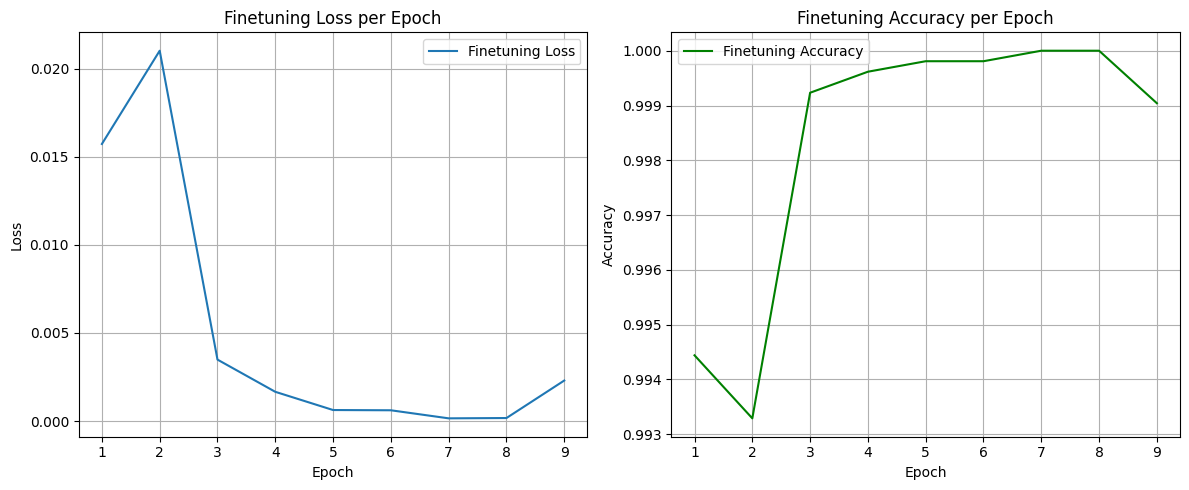

✅ Saved Fine-tuned ResNet A to /content/drive/MyDrive/ResNet_A_finetuned.pth


In [ ]:
from torch.amp import autocast, GradScaler
import torch.optim as optim
from tqdm.notebook import tqdm # Added this import
import torch.nn as nn # Added this import

print("\n--- Fine-tuning ResNet Model A (Unfrozen) ---")

# Unfreeze all parameters of the model
for param in resnet_A.parameters():
    param.requires_grad = True

# Create a new optimizer for the entire model
# Using a smaller learning rate for fine-tuning
optimizer_A_finetune = optim.Adam(resnet_A.parameters(), lr=0.0001)

resnet_A.train()

# Define the criterion here to ensure it's in scope
criterion = nn.CrossEntropyLoss()

# Continue training for a few more epochs with the unfrozen model
finetune_epochs = 9 # You can adjust this number

history_A_finetune_loss = []
history_A_finetune_acc = []

# Initialize the scaler
scaler = GradScaler('cuda') ## need to be applied in loop below- insert autocast

for epoch in range(finetune_epochs):
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    for inputs, labels in tqdm(train_loader, desc=f"Finetune Epoch {epoch+1}/{finetune_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer_A_finetune.zero_grad()

        # Use autocast for mixed precision training
        with autocast(device_type='cuda', dtype=torch.float16):
            outputs = resnet_A(inputs)
            loss = criterion(outputs, labels)

        # 2. SCALING: Scale the loss before generating the gradients
        scaler.scale(loss).backward()

        # 3. STEPPING: Use the scaler to step the optimizer
        scaler.step(optimizer_A_finetune)

        # 4. UPDATING: Update the scaler multiplier for the next batch
        scaler.update()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct_predictions / total_predictions
    history_A_finetune_loss.append(epoch_loss)
    history_A_finetune_acc.append(epoch_acc)
    print(f"Finetune Epoch {epoch+1}/{finetune_epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

# Plotting fine-tuning loss and accuracy
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, finetune_epochs + 1), history_A_finetune_loss, label='Finetuning Loss')
plt.title('Finetuning Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, finetune_epochs + 1), history_A_finetune_acc, label='Finetuning Accuracy', color='green')
plt.title('Finetuning Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Save the fine-tuned Model A
path_A_finetuned = '/content/drive/MyDrive/ResNet_A_finetuned.pth'
torch.save(resnet_A.state_dict(), path_A_finetuned)
print(f"✅ Saved Fine-tuned ResNet A to {path_A_finetuned}")

In [ ]:
print("\n--- Evaluating Fine-tuned ResNet Model A on Test Set ---")

resnet_A.eval()  # Set the model to evaluation mode
correct_finetuned = 0
total_finetuned = 0

with torch.no_grad():  # Disable gradient calculation during evaluation
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = resnet_A(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total_finetuned += labels.size(0)
        correct_finetuned += (predicted == labels).sum().item()

test_accuracy_finetuned = correct_finetuned / total_finetuned
print(f'Accuracy of Fine-tuned ResNet Model A on the test images: {100 * test_accuracy_finetuned:.2f}%')


--- Evaluating Fine-tuned ResNet Model A on Test Set ---
Accuracy of Fine-tuned ResNet Model A on the test images: 89.26%
